In [3]:
# Import libraries
import rapids_singlecell as rsc
import scanpy as sc
import cupy as cp
import numpy as np
import pandas as pd
import anndata
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# Set seed
np.random.seed(712)

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column width
pd.set_option("display.max_colwidth", None)

base_dir = "/tgen_labs/banovich/xenium_run_folders/big_baby_lung_BBL/"

In [4]:
# Allow oversubscription of memory
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

rmm.reinitialize(
    managed_memory=True,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

### PREPROCESSING AND ANNDATA OBJECT CREATION

In [5]:
# Read in all .h5 and metadata files 
feature_files = glob.glob(os.path.join(base_dir, "**", "cell_feature_matrix.h5"), recursive=True)        # cell feature matrices
transcript_files = glob.glob(os.path.join(base_dir, "**", "transcripts.parquet"), recursive=True)          # transcript files
meta_files = glob.glob(os.path.join(base_dir, "**", "cells.csv.gz"), recursive=True)        # cell metadata

# Ensure that all files are in the same order
feature_files.sort()
transcript_files.sort()
meta_files.sort()

In [6]:
feature_files
transcript_files
meta_files

[]

In [ ]:
# Read all AnnData objects into a list
adatas = None
for feature_file, meta_file, transcript_file in zip(feature_files, meta_files, transcript_files):
    a = sc.read_10x_h5(feature_file)

    print("a")

    # Cell metadata
    meta = pd.read_csv(meta_file, index_col=0)
    a.obs = meta.loc[a.obs_names].copy()

    # Transcript-level data
    transcripts = pd.read_parquet(transcript_file)

    print("b")

    # Filter transcripts
    transcripts = (
        transcripts
            .loc[~transcripts["feature_name"].str.contains(r"NegControl|Codeword|Intergenic|Blank|ControlProbe", regex=True)]  # drop genes with these strings
            .loc[transcripts["qv"] > 20]  # keep only QV > 20
    )

    transcript_counts = (
        transcripts.groupby(["cell_id", "feature_name"]).size()
        .unstack(fill_value=0)
    )

    print("c")
    
    # Make sure cell IDs align with AnnData
    transcript_counts = transcript_counts.reindex(a.obs_names).fillna(0)

    a.layers["transcript_counts"] = transcript_counts.values

    # Track TMA origin
    tma_id = os.path.basename(os.path.dirname(feature_file))
    a.obs["tma"] = tma_id

    # Adding row as cell_id
    a.obs["cell_id"] = a.obs_names

    if adatas is None:
        adatas = a
    else:
        adatas = sc.concat([adatas, a], join='outer')

a
b


/tmp/ipykernel_3604168/168163960.py:26: PerformanceWarning: The following operation may generate 5492608302 cells in the resulting pandas object.
  .unstack(fill_value=0)


c
a
b
c


/home/smallapragada/.local/lib/python3.13/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


a
b


/tmp/ipykernel_3604168/168163960.py:26: PerformanceWarning: The following operation may generate 5524229625 cells in the resulting pandas object.
  .unstack(fill_value=0)


c


In [6]:
# Merge all AnnData objects into one
adata = sc.concat(adatas, join="outer")

/home/smallapragada/.local/lib/python3.13/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [7]:
# Add cell ids as a column from rownames 
adata.obs["cell_id"] = adata.obs_names

# Gene x cell metrics
adata.obs["n_counts"] = adata.X.sum(axis=1).A1
adata.obs["n_genes"] = (adata.X > 0).sum(axis=1).A1
adata.obs["mean_counts_per_gene"] = adata.obs["n_counts"] / adata.obs["n_genes"]

# Replace TMA ID
adata.obs = (
    adata.obs
    .assign(tma=lambda d: d["tma"].str.extract(r"(PDLTMA\d+)"))
)

# Duplicating x and y coords columns
adata.obs["adj_x_centroid"] = adata.obs["x_centroid"]
adata.obs["adj_y_centroid"] = adata.obs["y_centroid"]

# Adjust columns
new_order = ["cell_id", "x_centroid", "y_centroid", "adj_x_centroid", "adj_y_centroid", "control_probe_counts", "genomic_control_counts", "control_codeword_counts",
            "unassigned_codeword_counts", "deprecated_codeword_counts", "transcript_counts", "total_counts", "segmentation_method", 
            "cell_area", "nucleus_area", "tma", "n_counts", "n_genes", "mean_counts_per_gene"]
adata.obs = adata.obs.loc[:, new_order]

In [15]:
adata.obs.head()

,cell_id,x_centroid,y_centroid,adj_x_centroid,adj_y_centroid,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,transcript_counts,total_counts,segmentation_method,cell_area,nucleus_area,tma,n_counts,n_genes,mean_counts_per_gene
aaaaaaei-1,aaaaaaei-1,432.988098,1054.764648,432.988098,1054.764648,0,0,0,0,0,478,478,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin),63.489690,40.369689,PDLTMA1,478.0,152,3.144737
aaaaaeoi-1,aaaaaeoi-1,440.791260,1098.254517,440.791260,1098.254517,0,0,0,0,0,450,450,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin),60.012658,39.331095,PDLTMA1,450.0,156,2.884615
aaaaahog-1,aaaaahog-1,437.497711,1044.279297,437.497711,1044.279297,0,0,0,0,0,438,438,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin),73.649846,38.427970,PDLTMA1,438.0,133,3.293233
aaaaainh-1,aaaaainh-1,443.901398,1954.962036,443.901398,1954.962036,0,0,0,0,0,309,309,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin),46.601252,27.229220,PDLTMA1,309.0,92,3.358696
aaaabkif-1,aaaabkif-1,455.337921,1970.503052,455.337921,1970.503052,0,0,0,0,0,415,415,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin),58.116096,36.486251,PDLTMA1,415.0,111,3.738739


In [10]:
# Save for further use
adata.write_h5ad("/scratch/smallapragada/bbl_project/objects/tma1_2_3_4_5_7_unfiltered_2025_09_03.h5ad")

... storing 'cell_id' as categorical
... storing 'segmentation_method' as categorical
... storing 'tma' as categorical


In [4]:
adata.obs.head()

,cell_id,x_centroid,y_centroid,adj_x_centroid,adj_y_centroid,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,transcript_counts,total_counts,segmentation_method,cell_area,nucleus_area,tma,n_counts,n_genes,mean_counts_per_gene
aaaaaaei-1,aaaaaaei-1,432.988098,1054.764648,432.988098,1054.764648,0,0,0,0,0,478,478,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin),63.489690,40.369689,PDLTMA1,478.0,152,3.144737
aaaaaeoi-1,aaaaaeoi-1,440.791260,1098.254517,440.791260,1098.254517,0,0,0,0,0,450,450,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin),60.012658,39.331095,PDLTMA1,450.0,156,2.884615
aaaaahog-1,aaaaahog-1,437.497711,1044.279297,437.497711,1044.279297,0,0,0,0,0,438,438,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin),73.649846,38.427970,PDLTMA1,438.0,133,3.293233
aaaaainh-1,aaaaainh-1,443.901398,1954.962036,443.901398,1954.962036,0,0,0,0,0,309,309,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin),46.601252,27.229220,PDLTMA1,309.0,92,3.358696
aaaabkif-1,aaaabkif-1,455.337921,1970.503052,455.337921,1970.503052,0,0,0,0,0,415,415,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin),58.116096,36.486251,PDLTMA1,415.0,111,3.738739


### SAMPLE SPLITTING

In [7]:
cell_stats = sorted(glob.glob(os.path.join(base_dir, "**", "*_cells_stats.csv"), recursive=True))

In [8]:
# Reading through all cell stats and adding a sample ID column
all_cell_stats = []  

for f in cell_stats:
    filename = Path(f).name
    
    if filename.startswith("TMA"):  # only process TMA files
        parts = filename.split("_")
        sample_name = parts[1]   
        tma_name = parts[0]
        
        df = pd.read_csv(f, skiprows=2)
        df["sample"] = sample_name
        df["tma"] = tma_name
        all_cell_stats.append(df)

# Combine everything into one DataFrame
cell_stats_df = pd.concat(all_cell_stats, ignore_index=True)

# Adding TMA name to cell_id
cell_stats_df["Cell ID"] = "PDL" + cell_stats_df["tma"] + "_" + cell_stats_df["Cell ID"].astype(str)

# Rename cell id column name to match metadata
cell_stats_df_new = cell_stats_df.rename(columns={"Cell ID": "cell_id"})

In [9]:
cell_stats_df_new.groupby(['sample']).size()

sample
PDL018A      60832
PDL018T      34297
PDL019A     110625
PDL019D      35929
PDL019T      23782
PDL020D      49470
PDL021A      74981
PDL021D      28703
PDL022A      79122
PDL022D      83940
PDL023D     100207
PDL023T      33375
PDL024A      55957
PDL024T      20700
PDL025A     116880
PDL025D     103566
PDL025T      34605
PDL026D      84911
PDL026T      18103
PDL027A      91610
PDL027D      35435
PDL027T      74406
PDL028A      93355
PDL028T      37706
PDL029D      92592
PDL030A      78611
PDL030D      86242
PDL031D     103084
PDL031T      10321
PDL032A1     98426
PDL032A2     77659
PDL032T       8506
PDL033D     113450
PDL034A     135561
PDL034T      27292
PDL035A      69588
PDL035D      67132
PDL035T      11622
PDL036A     130182
PDL036T      15521
PDL037A     110004
PDL037D     118738
PDL037T      28569
PDL038A     120506
PDL038T      20903
PDL039A      59379
PDL039D      54981
PDL040D      64690
PDL040T       2187
PDL041D      63833
PDL041T      27571
PDL042A      38391
PDL04

In [49]:
# Adding TMA name to cell_id
adata.obs["tma"] = adata.obs["tma"].astype(str)
adata.obs["cell_id"] = adata.obs["tma"] + "_" + adata.obs["cell_id"].astype(str)
adata.obs_names = adata.obs["cell_id"].astype(str)  # set new IDs

In [10]:
print(adata.obs_names[:5])

Index(['PDLTMA3_aaaaaddf-1', 'PDLTMA3_aaaaanhj-1', 'PDLTMA3_aaaabpom-1',
       'PDLTMA3_aaaacanj-1', 'PDLTMA3_aaaaclck-1'],
      dtype='object', name='cell_id')


In [11]:
# Checking common IDs
common_ids = set(adata.obs["cell_id"]) & set(cell_stats_df_new["cell_id"])
print("Number of overlapping cell_ids:", len(common_ids))

only_in_adata = set(adata.obs["cell_id"]) - set(cell_stats_df_new["cell_id"])
only_in_meta = set(cell_stats_df_new["cell_id"]) - set(adata.obs["cell_id"])
print("Cells only in adata.obs:", len(only_in_adata))
print("Cells only in cell_stats:", len(only_in_meta))

Number of overlapping cell_ids: 6995621
Cells only in adata.obs: 8365
Cells only in cell_stats: 1096930


In [66]:
cell_stats_df_new.head()

,cell_id,Cluster,Transcripts,Area (µm^2),sample,tma
0,PDLTMA1_miikcmae-1,Cluster 16,0,17.64,PDL018T,TMA1
1,PDLTMA1_miiliipl-1,Cluster 2,0,21.80,PDL018T,TMA1
2,PDLTMA1_miikgnkl-1,Cluster 14,0,35.66,PDL018T,TMA1
3,PDLTMA1_miikhkem-1,Cluster 16,0,20.43,PDL018T,TMA1
4,PDLTMA1_miiklgfp-1,Cluster 2,0,20.95,PDL018T,TMA1


In [12]:
# Ensure cell_id → sample mapping is unique
sample_df = cell_stats_df_new[['cell_id', 'sample']].drop_duplicates(subset='cell_id').set_index('cell_id')

# Add sample column aligned to AnnData, fill missing with "UNSURE"
adata.obs['sample'] = sample_df.reindex(adata.obs.index)['sample'].fillna('UNSURE')

In [15]:
len(adata.obs)

7003986

In [16]:
adata.obs.groupby(['sample']).size().sum()

np.int64(7003986)

In [26]:
# Adjusting coordinates based on TMA
# adata.obs.loc[adata.obs["tma"].eq("PDLTMA2"), "adj_x_centroid"] = (
#     adata.obs.loc[adata.obs["tma"].eq("PDLTMA2"), "adj_x_centroid"].to_numpy() - 15000
# )

# adata.obs.loc[adata.obs["tma"].eq("PDLTMA3"), "adj_x_centroid"] = (
#     adata.obs.loc[adata.obs["tma"].eq("PDLTMA3"), "adj_x_centroid"].to_numpy() + 30000
# )

# adata.obs.loc[adata.obs["tma"].eq("PDLTMA4"), "adj_x_centroid"] = (
#     adata.obs.loc[adata.obs["tma"].eq("PDLTMA4"), "adj_x_centroid"].to_numpy() + 45000
# )

adata.obs.loc[adata.obs["tma"].eq("PDLTMA5"), "adj_y_centroid"] = (
    adata.obs.loc[adata.obs["tma"].eq("PDLTMA5"), "adj_y_centroid"].to_numpy() - 20000
)

adata.obs.loc[adata.obs["tma"].eq("PDLTMA7"), "adj_x_centroid"] = (
    adata.obs.loc[adata.obs["tma"].eq("PDLTMA7"), "adj_x_centroid"].to_numpy() + 45000
)
adata.obs.loc[adata.obs["tma"].eq("PDLTMA7"), "adj_y_centroid"] = (
    adata.obs.loc[adata.obs["tma"].eq("PDLTMA7"), "adj_y_centroid"].to_numpy() - 20000
)

In [17]:
adata.obs.loc[adata.obs["tma"] == "PDLTMA2", "adj_x_centroid"].head()

cell_id
PDLTMA2_aaaaaokh-1    15531.105713
PDLTMA2_aaaaipab-1    15538.483154
PDLTMA2_aaaakfhb-1    15536.632629
PDLTMA2_aaaalccl-1    15512.362793
PDLTMA2_aaaamaik-1    15537.415344
Name: adj_x_centroid, dtype: float64

In [19]:
# Add spatial coordinates from metadata
coords = adata.obs[["adj_x_centroid", "adj_y_centroid"]].values  # shape (n_obs, 2)
adata.obsm["spatial"] = coords

# Add coordinates into obs from obsm
adata.obs['adj_x_centroid'] = adata.obsm['spatial'][:, 0]
adata.obs['adj_y_centroid'] = adata.obsm['spatial'][:, 1]

# Check
print(adata.obsm["spatial"].shape)

(7003986, 2)


In [22]:
# Ensure no missing values
adata_plot = adata[~adata.obs[['adj_x_centroid','adj_y_centroid']].isna().any(axis=1)].copy()

In [24]:
print("adata.X rows:", adata.n_obs)
print("adata.obs rows:", adata.obs.shape[0])

adata.X rows: 7003986
adata.obs rows: 7003986


In [26]:
# Convert sample to string (if needed)
adata_plot.obs['sample'] = adata_plot.obs['sample'].astype(str)

IndexError: index 101 is out of bounds for axis 0 with size 101

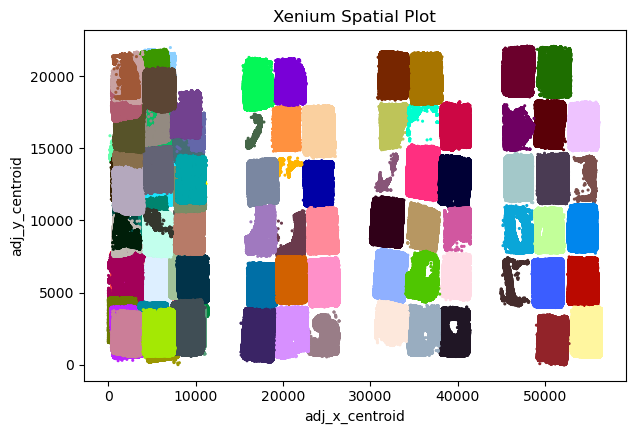

In [27]:
# spatial plot
sc.pl.scatter(
    adata,
    x='adj_x_centroid',
    y='adj_y_centroid',
    color='sample',  # or 'sample', 'cluster', etc.
    title='Xenium Spatial Plot',
    size=20  # adjust for readability
)

### QC AND FILTERING 

In [28]:
# Easily view cell x gene matrix 
def preview_X(
    adata,
    cells=None,   
    genes=None,   
    n_obs=20,
    n_vars=480):
    
    # Decide which cells
    if cells is not None:
        cell_idx = adata.obs_names.get_indexer(cells)
    else:
        cell_idx = range(min(n_obs, adata.n_obs))
    
    # Decide which genes
    if genes is not None:
        gene_idx = adata.var_names.get_indexer(genes)
    else:
        gene_idx = range(min(n_vars, adata.n_vars))
    
    # Slice X
    X_sub = adata.X[cell_idx, :][:, gene_idx]
    if hasattr(X_sub, "toarray"):  # convert if sparse
        X_sub = X_sub.toarray()
    
    return pd.DataFrame(
        X_sub,
        index=adata.obs_names[cell_idx],
        columns=adata.var_names[gene_idx]
    )

In [29]:
preview_X(adata)

,ABHD16A,ACAA2,ACKR1,ACSL3,ACTA2,ADAMTS1,ADGRF5,ADGRL4,AGER,AGR3,AIF1,AKAP13,AKR1C1,ALDH1A1,ANKRD1,ANTXR2,APLN,APLNR,APOE,APOLD1,AQP5,AREG,ARF6,ARL4A,ARPC1B,ASPN,ATF3,ATF4,ATG7,ATP5MF,AXL,BANK1,BAX,BCL2,BCL2L1,BCL2L11,BMP4,BMPR2,BPIFA1,BPIFB1,BTG2,BZW1,C1D,C1QC,C20orf85,C7,C9orf72,CA4,CCDC32,CCDC78,CCL18,CCL2,CCL22,CCL5,CCN2,CCT8,CD14,CD151,CD163,CD19,CD1C,CD1E,CD2,CD247,CD27,CD28,CD34,CD36,CD3D,CD3E,CD3G,CD4,CD44,CD47,CD52,CD68,CD69,CD79A,CD79B,CD8A,CD8B,CDH1,CDH26,CDK1,CEACAM5,CEACAM6,CENPF,CES1,CFH,CFTR,CH25H,CHCHD6,CHCHD7,CHI3L1,CHIT1,CHMP5,CHP1,CHST12,CKS1B,CLDN4,CLDN5,COL15A1,COL1A1,COL1A2,COL2A1,COL3A1,COL4A1,COL4A3,COMMD6,COMMD9,COX4I2,CP,CPA3,CPE,CPM,CSPG4,CTHRC1,CTSD,CXCL12,CXCL13,CXCL14,CXCL6,CXCR4,CYP2F1,DCN,DCP2,DECR1,DERL3,DES,DGKG,DKK2,DMBT1,DNAH10,DNAH12,DNAJB9,DUOX1,EDNRB,EGFR,ELANE,ELN,ELOVL5,EMC7,EP400,EPAS1,EPCAM,EPS8,EREG,ERLEC1,ERN2,ETS2,ETV5,EXOC4,FABP4,FAM13A,FAM3B,FANK1,FAP,FARP1,FASN,FCER1A,FCER1G,FCGBP,FCGR3A,FCN1,FCN3,FGF10,FGF18,FGF2,FGF7,FGFBP2,FGFR4,FILIP1L,FKBP11,FN1,FOXF1,FOXJ1,FRMD4B,FSTL1,GATA6,GBP1,GBP2,GCLM,GDF15,GJA5,GKN2,GNB2,GNG11,GNLY,GPR183,GSAP,GSR,GZMA,GZMB,HAS1,HDAC9,HES1,HEY1,HHIP,HIF1A,HLA-DQA1,HLA-DQB1,HLA-DRA,HLA-DRB5,HMGA1,HMOX1,HOPX,HRAS,HSPG2,ICAM1,ID2,ID4,IDH1,IFI16,IFIT1,IFITM1,IFITM2,IFITM3,IFT43,IFT57,IGF1,IGFBP3,IGFBP5,IL32,IL4R,IL7R,INHBA,INMT,INTS10,IRF1,IRF7,ITGA3,ITGA6,ITGAV,ITGB1,ITGB6,ITM2C,IVD,KANSL1,KANSL1-AS1,KCNK3,KDR,KIT,KLK11,KLRB1,KLRC1,KLRG1,KRT14,KRT15,KRT17,KRT18,KRT5,KRT6A,KRT8,LAMA3,LAMA5,LAMC3,LAMP3,LAMTOR4,LAPTM4A,LCK,LEF1,LGR5,LILRA4,LITAF,LMO3,LRRC34,LRRIQ1,LSP1,LTA4H,LTB,LTBP2,LTC4S,LTF,LUM,LYVE1,LYZ,MAD1L1,MALSU1,MANF,MAP2K2,MARCO,MCEMP1,MEG3,MFAP5,MGP,MGST1,MKI67,MLPH,MMP10,MMP12,MMP7,MMRN1,MORF4L1,MOXD1,MRC1,MS4A1,MS4A7,MSLN,MUC5AC,MUC5B,MYC,MYH11,MYL4,MZB1,NAPSA,NDUFA12,NDUFA4L2,NDUFA8,NFKB1,NFKBIA,NKD1,NKG7,NKX2-1,NOTCH3,NPNT,NRP1,NSF,NTN4,NUCB2,NUTF2,PCM1,PCNP,PDE4D,PDGFRA,PDGFRB,PDIA4,PDK4,PECAM1,PGC,PHAX,PI16,PIFO,PIM2,PLIN2,PLN,PLPP1,PLPP5,PLVAP,PLXNA4,POLR2L,POSTN,PPA2,PPARG,PRDX4,PROM1,PROX1,PSMB9,PTGDS,PTGS1,PTPN6,PTPRC,PTTG1,RAMP2,RBP4,RNASE1,RNASEH2C,RNH1,RPP25L,RSF1,RSPO2,RSPO3,RTKN2,RUNX1,S100A12,S100A14,S100A2,S100A4,S100A8,S100A9,SAA2,SCEL,SCGB1A1,SCGB3A2,SEC61A1,SECISBP2L,SELL,SEM1,SEMA3A,SEMA3B,SEMA3C,SERPINF1,SFRP1,SFRP2,SFRP4,SFTA2,SFTPC,SFTPD,SHANK3,SHH,SIPA1L1,SLC1A3,SLC25A37,SLC25A4,SLIT3,SLU7,SMAD4,SMAP1,SMPD3,SNAI1,SNAI2,SOD2,SOX2,SOX4,SOX9,SPARCL1,SPATS2L,SPINK1,SPOCK2,SPP1,SPRY1,SPRY2,SRP14,SRRM1,SRSF1,SRSF5,SSR1,SSR3,STARD3NL,STAT1,STAT6,SVEP1,SYT8,TACSTD2,TALDO1,TBC1D1,TBX4,TCF21,TCL1A,TGFB1,TGFB2,TGFB3,TGFBI,TGFBR2,TIMP1,TLE4,TMEM100,TMEM170A,TMEM179B,TMEM223,TMEM33,TMPRSS2,TNFRSF13C,TNNI2,TOLLIP,TOP2A,TP53,TP63,TP73,TPSAB1,TRAC,TRAF3IP1,TREM2,TRIM4,TRIM47,TRPC6,TSPAN4,TSPAN8,TTYH3,UBE2J1,UBL3,UNC119,UPK3B,VCAN,VEGFA,VIM,VWF,WFDC2,WNT11,WNT2,WNT3A,WNT5A,WNT7B,WT1,WTAP,WWTR1,XBP1,YWHAG,ZBTB16,ZEB1,ZFAND2A
cell_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PDLTMA3_aaaaaddf-1,1.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,8.0,5.0,0.0,0.0,0.0,0.0,0.0

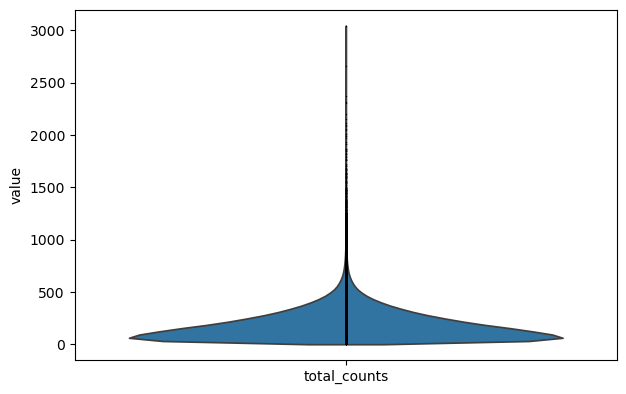

In [33]:
sc.pl.violin(
    adata,
    ["total_counts"],
    jitter=0
)

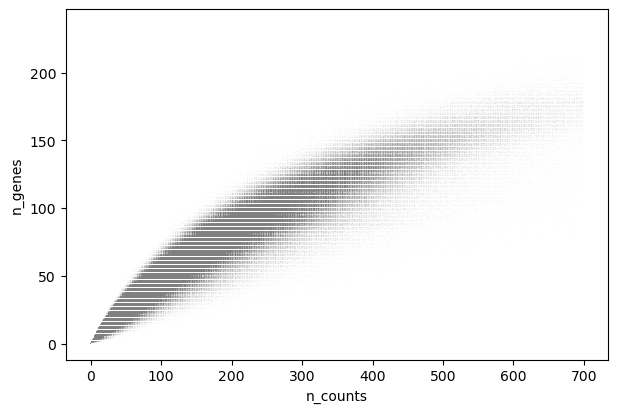

In [37]:
sc.pl.scatter(adata[adata.obs["n_counts"] < 700, :],
              "n_counts", 
              "n_genes"
             )

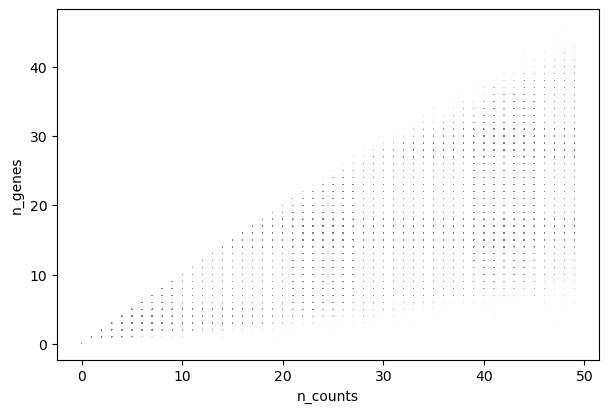

In [38]:
sc.pl.scatter(adata[adata.obs["n_counts"] < 50, :],
              "n_counts", 
              "n_genes"
             )

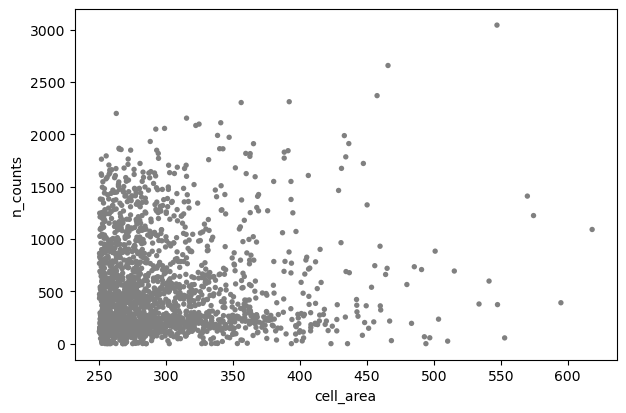

In [21]:
# Filter out cell_area < 5.0 & > 250

# sc.pl.scatter(adata[adata.obs["cell_area"] < 20, :],
#               "cell_area", 
#               "n_counts"
#              )

sc.pl.scatter(adata[adata.obs["cell_area"] > 250, :],
              "cell_area", 
              "n_counts"
             )

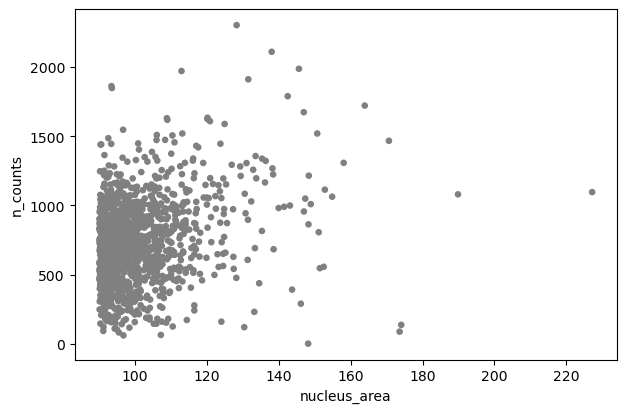

In [25]:
# Filter out nucleus_area < 4.5
sc.pl.scatter(adata[adata.obs["nucleus_area"] < 6, :],
              "nucleus_area", 
              "n_counts"
             )

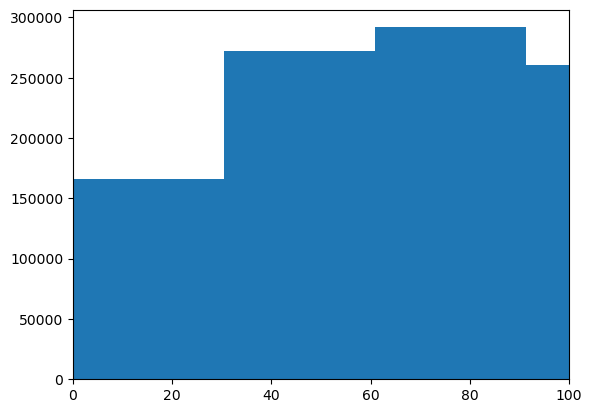

In [51]:
# Filter out n_count < 25
plt.hist(adata.obs["n_counts"], bins=100)
plt.xlim(0, 100)
plt.show()

In [30]:
# Filtering out cells based on QC metrics
adata_filtered = adata[adata.obs['n_counts'] >= 25]
adata_filtered = adata_filtered[adata_filtered.obs['n_genes'] >= 10]
adata_filtered = adata_filtered[adata_filtered.obs['cell_area'] >= 5]
adata_filtered = adata_filtered[adata_filtered.obs['cell_area'] <= 250]
adata_filtered = adata_filtered[adata_filtered.obs['nucleus_area'] >= 4.5]

In [31]:
adata

AnnData object with n_obs × n_vars = 7003986 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'adj_x_centroid', 'adj_y_centroid', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'transcript_counts', 'total_counts', 'segmentation_method', 'cell_area', 'nucleus_area', 'tma', 'n_counts', 'n_genes', 'mean_counts_per_gene', 'sample'
    uns: 'sample_colors'
    obsm: 'spatial'
    layers: 'transcript_counts'

In [32]:
adata_filtered

View of AnnData object with n_obs × n_vars = 6350176 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'adj_x_centroid', 'adj_y_centroid', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'transcript_counts', 'total_counts', 'segmentation_method', 'cell_area', 'nucleus_area', 'tma', 'n_counts', 'n_genes', 'mean_counts_per_gene', 'sample'
    obsm: 'spatial'
    layers: 'transcript_counts'

### AIRWAY CELL CONFIDENCE THRESHOLD

In [33]:
gene = "TP63"  
gene_idx = adata_filtered.var_names.get_loc(gene)

# Get expression data
if hasattr(adata_filtered.X, "toarray"):
    values = adata_filtered.X[:, gene_idx].toarray().flatten()
else:
    values = adata_filtered.X[:, gene_idx]

freq_table = pd.Series(values).value_counts().sort_index()
print(freq_table)

#plt.bar(freq_table.index, freq_table.values, color='skyblue')
#plt.xticks(freq_table.index)  
#plt.show()

0.0     6256079
1.0       63846
2.0       12750
3.0        6233
4.0        3610
5.0        2376
6.0        1606
7.0        1061
8.0         798
9.0         507
10.0        350
11.0        253
12.0        200
13.0        161
14.0        105
15.0         63
16.0         48
17.0         32
18.0         28
19.0         21
20.0          8
21.0          4
22.0          8
23.0          7
24.0          3
25.0          4
26.0          2
27.0          2
28.0          3
30.0          1
31.0          1
32.0          1
33.0          2
34.0          2
41.0          1
Name: count, dtype: int64


In [36]:
gene_idx = adata_filtered.var_names.get_loc("KRT5")

# Get expression data
if hasattr(adata_filtered.X, "toarray"):
    values = adata_filtered.X[:, gene_idx].toarray().flatten()
else:
    values = adata_filtered.X[:, gene_idx]

freq_table = pd.Series(values).value_counts().sort_index()
print(freq_table)

#plt.bar(freq_table.index, freq_table.values, color='skyblue')
#plt.xticks(freq_table.index)  
#plt.show()

0.0      6251967
1.0        40918
2.0        11567
3.0         6441
4.0         4562
5.0         3526
6.0         2774
7.0         2305
8.0         2016
9.0         1749
10.0        1625
11.0        1494
12.0        1305
13.0        1264
14.0        1167
15.0        1084
16.0        1003
17.0         939
18.0         849
19.0         829
20.0         743
21.0         707
22.0         642
23.0         597
24.0         578
25.0         503
26.0         493
27.0         441
28.0         452
29.0         435
30.0         389
31.0         351
32.0         334
33.0         301
34.0         273
35.0         243
36.0         220
37.0         236
38.0         198
39.0         180
40.0         177
41.0         185
42.0         161
43.0         142
44.0         138
45.0         123
46.0         116
47.0         107
48.0          84
49.0          94
50.0          67
51.0          79
52.0          63
53.0          86
54.0          61
55.0          47
56.0          50
57.0          50
58.0          

In [11]:
gene_idx = adata_filtered.var_names.get_loc("SCGB1A1")

# Get expression data
if hasattr(adata_filtered.X, "toarray"):
    values = adata_filtered.X[:, gene_idx].toarray().flatten()
else:
    values = adata_filtered.X[:, gene_idx]

freq_table = pd.Series(values).value_counts().sort_index()
print(freq_table)

#plt.bar(freq_table.index, freq_table.values, color='skyblue')
#plt.xticks(freq_table.index)  
#plt.show()

0.0      6237829
1.0        55843
2.0        14184
3.0         7351
4.0         4816
5.0         3534
6.0         2874
7.0         2401
8.0         1945
9.0         1631
10.0        1463
11.0        1345
12.0        1132
13.0        1020
14.0         919
15.0         821
16.0         718
17.0         685
18.0         632
19.0         588
20.0         529
21.0         498
22.0         466
23.0         461
24.0         372
25.0         388
26.0         330
27.0         284
28.0         291
29.0         256
30.0         229
31.0         229
32.0         242
33.0         209
34.0         197
35.0         208
36.0         188
37.0         202
38.0         164
39.0         147
40.0         153
41.0         145
42.0         122
43.0         128
44.0         101
45.0          94
46.0          91
47.0         108
48.0          94
49.0         106
50.0          73
51.0          59
52.0          80
53.0          70
54.0          51
55.0          59
56.0          66
57.0          56
58.0          

In [34]:
# Adding KRT5 expression to metadata
gene_idx = adata_filtered.var_names.get_loc("KRT5")

if hasattr(adata_filtered.X, "toarray"):
    values = adata_filtered.X[:, gene_idx].toarray().flatten()
else:
    values = adata_filtered.X[:, gene_idx]

df = adata_filtered.obs.copy()
df["KRT5"] = values

# Adding TP63 expression to metadata
gene_idx = adata_filtered.var_names.get_loc("TP63")

if hasattr(adata_filtered.X, "toarray"):
    values = adata_filtered.X[:, gene_idx].toarray().flatten()
else:
    values = adata_filtered.X[:, gene_idx]

df["TP63"] = values

# Adding VIM expression to metadata
gene_idx = adata_filtered.var_names.get_loc("VIM")

if hasattr(adata_filtered.X, "toarray"):
    values = adata_filtered.X[:, gene_idx].toarray().flatten()
else:
    values = adata_filtered.X[:, gene_idx]

df["VIM"] = values

# Adding SCGB3A2 expression to metadata
gene_idx = adata_filtered.var_names.get_loc("SCGB3A2")

if hasattr(adata_filtered.X, "toarray"):
    values = adata_filtered.X[:, gene_idx].toarray().flatten()
else:
    values = adata_filtered.X[:, gene_idx]

df["SCGB3A2"] = values

# Adding SCGB1A1 expression to metadata
gene_idx = adata_filtered.var_names.get_loc("SCGB1A1")

if hasattr(adata_filtered.X, "toarray"):
    values = adata_filtered.X[:, gene_idx].toarray().flatten()
else:
    values = adata_filtered.X[:, gene_idx]

df["SCGB1A1"] = values

# Adding MUC5B expression to metadata
gene_idx = adata_filtered.var_names.get_loc("MUC5B")

if hasattr(adata_filtered.X, "toarray"):
    values = adata_filtered.X[:, gene_idx].toarray().flatten()
else:
    values = adata_filtered.X[:, gene_idx]

df["MUC5B"] = values

# Adding C20orf85 expression to metadata
gene_idx = adata_filtered.var_names.get_loc("C20orf85")

if hasattr(adata_filtered.X, "toarray"):
    values = adata_filtered.X[:, gene_idx].toarray().flatten()
else:
    values = adata_filtered.X[:, gene_idx]

df["C20orf85"] = values

# Add expression values to adata.obs
adata_filtered.obs["KRT5"] = df["KRT5"]
adata_filtered.obs["TP63"] = df["TP63"]
adata_filtered.obs["VIM"] = df["VIM"]
adata_filtered.obs["SCGB3A2"] = df["SCGB3A2"]
adata_filtered.obs["SCGB1A1"] = df["SCGB1A1"]
adata_filtered.obs["MUC5B"] = df["MUC5B"]
adata_filtered.obs["C20orf85"] = df["C20orf85"]

/tmp/ipykernel_1570620/2151226090.py:73: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_filtered.obs["KRT5"] = df["KRT5"]


In [35]:
# Subsetting different objects based on ++/+-
# adata_filtered_krt5 = adata_filtered[adata_filtered.obs["KRT5"] >= 1].copy()
# adata_filtered_tp63 = adata_filtered[adata_filtered.obs["TP63"] >= 1].copy()
# adata_filtered_krt5_tp63_1 = adata_filtered[(adata_filtered.obs["KRT5"] >= 1) & (adata_filtered.obs["TP63"] >= 1)].copy()
adata_filtered_krt5_tp63_2 = adata_filtered[(adata_filtered.obs["KRT5"] >= 2) & (adata_filtered.obs["TP63"] >= 2)].copy()

# adata_filtered_krt5_opp = adata_filtered[adata_filtered.obs["KRT5"] < 1].copy()
# adata_filtered_tp63_opp = adata_filtered[adata_filtered.obs["TP63"] < 1].copy()
# adata_filtered_krt5_tp63_1_opp = adata_filtered[(adata_filtered.obs["KRT5"] < 1) | (adata_filtered.obs["TP63"] < 1)].copy()
# adata_filtered_krt5_tp63_2_opp = adata_filtered[(adata_filtered.obs["KRT5"] < 2) | (adata_filtered.obs["TP63"] < 2)].copy()

In [36]:
adata_filtered_krt5_tp63_2

AnnData object with n_obs × n_vars = 22809 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'adj_x_centroid', 'adj_y_centroid', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'transcript_counts', 'total_counts', 'segmentation_method', 'cell_area', 'nucleus_area', 'tma', 'n_counts', 'n_genes', 'mean_counts_per_gene', 'sample', 'KRT5', 'TP63', 'VIM', 'SCGB3A2', 'SCGB1A1', 'MUC5B', 'C20orf85'
    obsm: 'spatial'
    layers: 'transcript_counts'

In [37]:
adata_filtered_krt5_tp63_2.obs.groupby(['sample']).size().sum()

/tmp/ipykernel_4078227/2355246750.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_filtered_krt5_tp63_2.obs.groupby(['sample']).size().sum()


np.int64(22799)

In [41]:
# 1️⃣ Ensure unique gene names
adata_filtered_krt5_tp63_2.var_names_make_unique()

# 2️⃣ Ensure all metadata strings are categorical
for col in adata_filtered_krt5_tp63_2.obs.columns:
    if adata_filtered_krt5_tp63_2.obs[col].dtype == 'object':
        adata_filtered_krt5_tp63_2.obs[col] = adata_filtered_krt5_tp63_2.obs[col].astype('category')

# 3️⃣ Ensure cell_id index does not conflict with a column
# If you want a column called 'cell_id', make it match the index
adata_filtered_krt5_tp63_2.obs['cell_id'] = adata_filtered_krt5_tp63_2.obs_names
adata_filtered_krt5_tp63_2.obs.index.name = 'cell_id'

# 4️⃣ Optional: remove extra var columns (metadata) that may cause misalignment
adata_filtered_krt5_tp63_2.var = pd.DataFrame(index=adata_filtered_krt5_tp63_2.var_names)  # keep only gene names

In [37]:
adata_filtered_krt5_tp63_2.obs_names

Index(['PDLTMA3_adlhcchi-1', 'PDLTMA3_adlhgbep-1', 'PDLTMA3_adlhjaii-1',
       'PDLTMA3_adlhlilc-1', 'PDLTMA3_adliafaf-1', 'PDLTMA3_adlicfdj-1',
       'PDLTMA3_adlichkc-1', 'PDLTMA3_adlickil-1', 'PDLTMA3_adljbkgc-1',
       'PDLTMA3_adljdghb-1',
       ...
       'PDLTMA7_npmmndhk-1', 'PDLTMA7_oegnhndm-1', 'PDLTMA7_oehppjdi-1',
       'PDLTMA7_oekialkh-1', 'PDLTMA7_oeknfadn-1', 'PDLTMA7_oemgkafj-1',
       'PDLTMA7_ofhnlfli-1', 'PDLTMA7_ofmjjdpm-1', 'PDLTMA7_ogelaehb-1',
       'PDLTMA7_oglpacmf-1'],
      dtype='object', name='cell_id', length=22809)

In [44]:
# Save for further use
adata_filtered_krt5_tp63_2.write_h5ad("/scratch/smallapragada/bbl_project/objects/tma1_2_3_4_5_7_filtered_basal_only_2025_09_09.h5ad")

#Save metadata as a separate object to integrate later on.
clustered_metadata = adata_filtered_krt5_tp63_2.obs
metadata = pd.DataFrame.to_csv(clustered_metadata, "/scratch/smallapragada/bbl_project/objects/tma1_2_3_4_5_7_filtered_basal_only_2025_09_09.csv")

... storing 'sample' as categorical
... storing 'disease_process' as categorical
... storing 'gest_age' as categorical
... storing 'samp_type' as categorical
... storing 'life_span_bin' as categorical


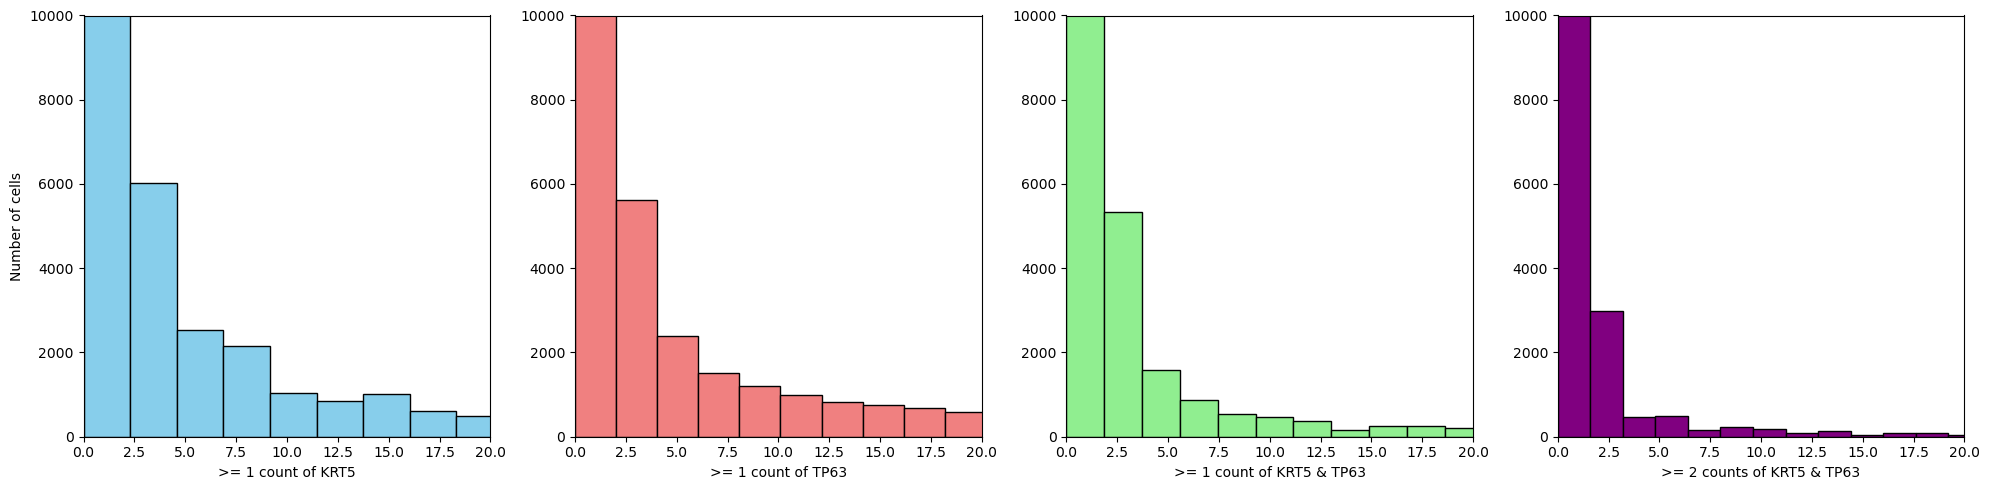

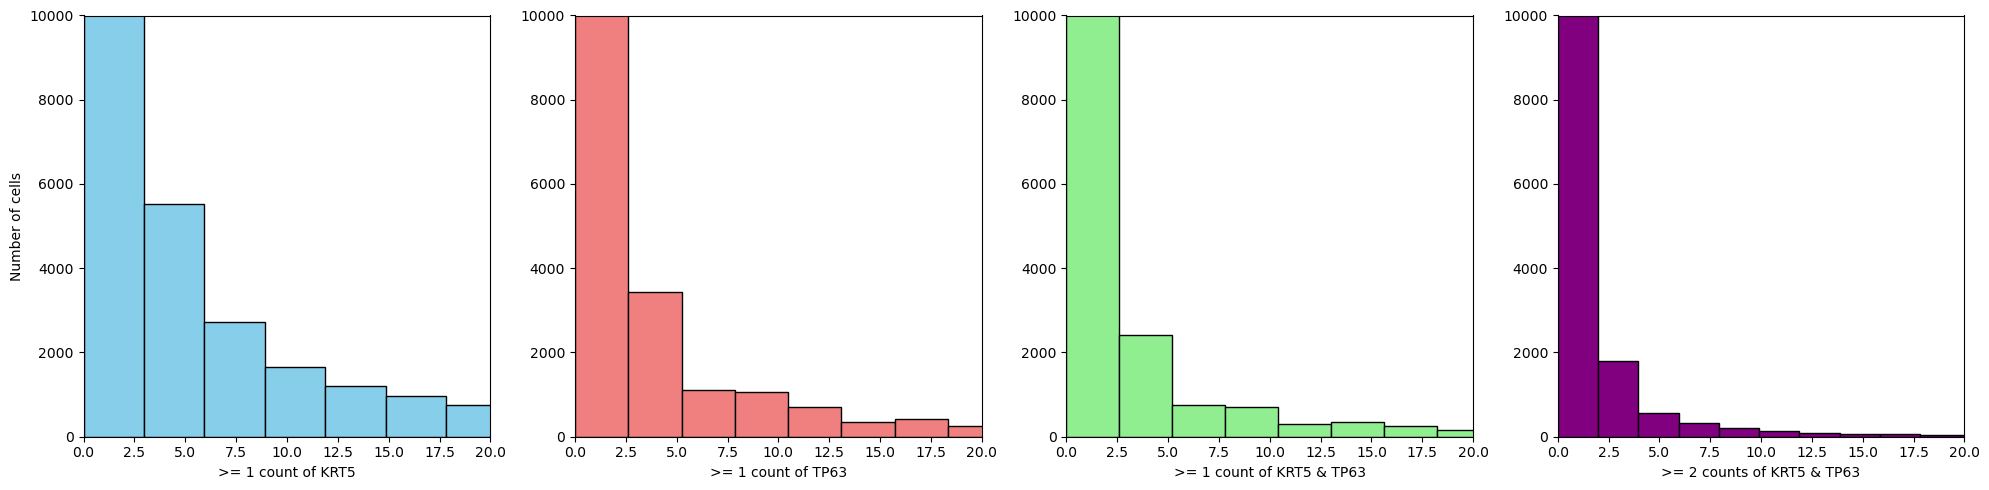

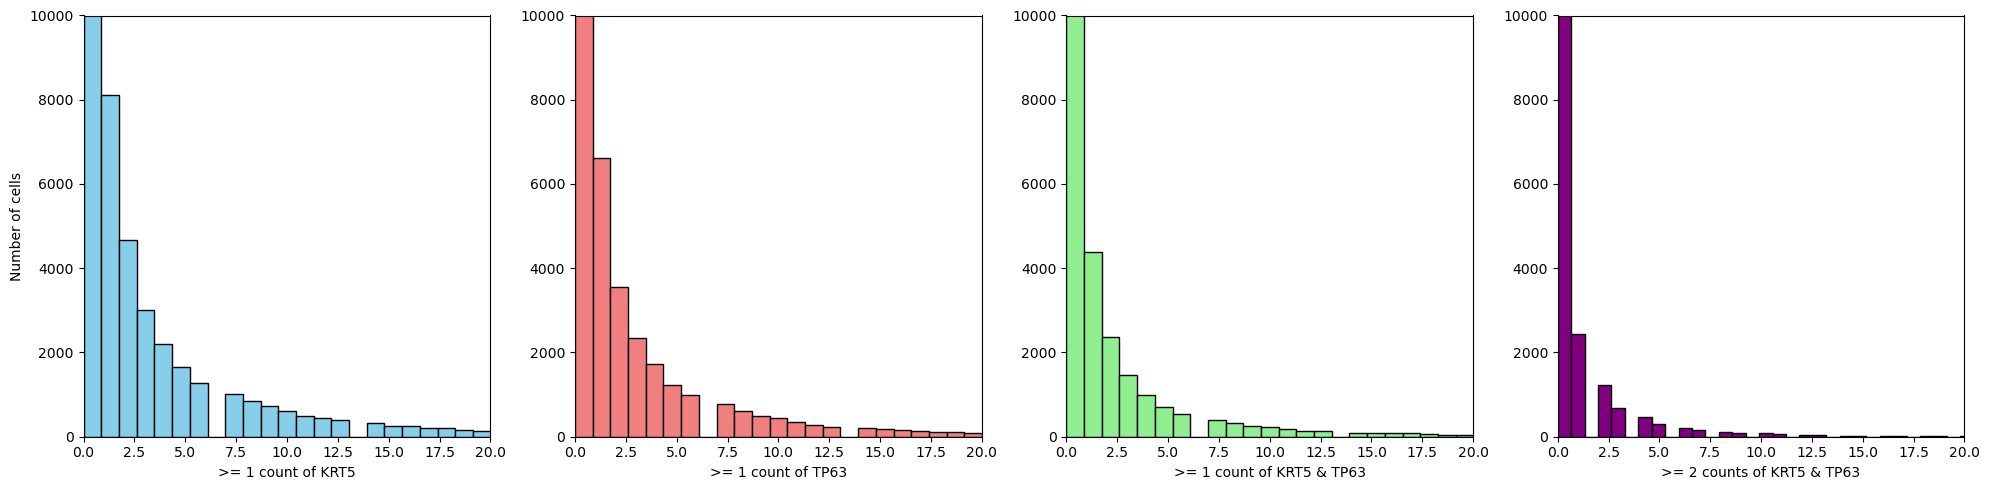

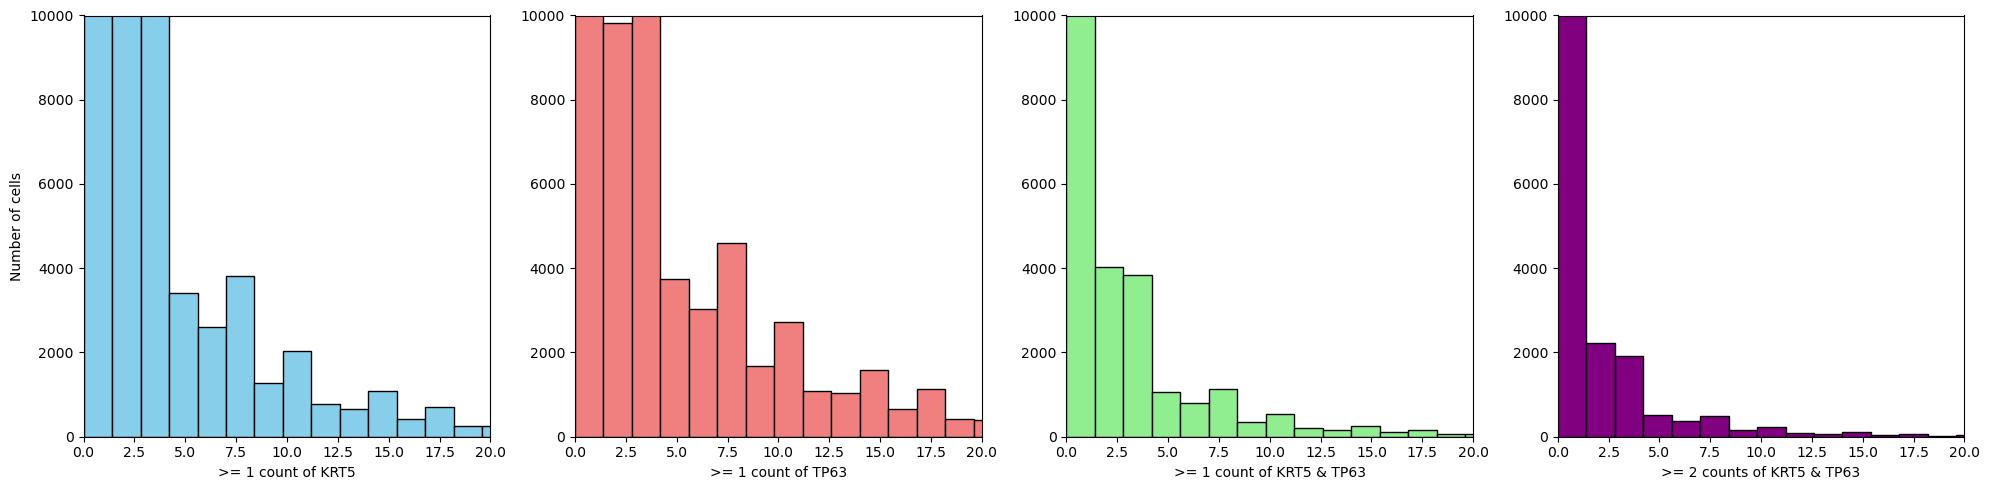

In [64]:
# Histogram plots of SCGB3A2 in cells with different basal cell thresholds
fig, axes = plt.subplots(1, 4, figsize=(20, 5)) 

axes[0].hist(adata_filtered_krt5.obs["SCGB3A2"], bins=100, color='skyblue', edgecolor='black')
axes[0].set_xlabel('>= 1 count of KRT5')
axes[0].set_ylabel('Number of cells')
axes[0].ticklabel_format(style="plain", axis="y")
axes[0].set_xlim(0, 20)
axes[0].set_ylim(0, 10000)

axes[1].hist(adata_filtered_tp63.obs["SCGB3A2"], bins=100, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('>= 1 count of TP63')
axes[1].ticklabel_format(style="plain", axis="y")
axes[1].set_xlim(0, 20)
axes[1].set_ylim(0, 10000)

axes[2].hist(adata_filtered_krt5_tp63_1.obs["SCGB3A2"], bins=100, color='lightgreen', edgecolor='black')
axes[2].set_xlabel('>= 1 count of KRT5 & TP63')
axes[2].ticklabel_format(style="plain", axis="y")
axes[2].set_xlim(0, 20)
axes[2].set_ylim(0, 10000)

axes[3].hist(adata_filtered_krt5_tp63_2.obs["SCGB3A2"], bins=100, color='purple', edgecolor='black')
axes[3].set_xlabel('>= 2 counts of KRT5 & TP63')
axes[3].ticklabel_format(style="plain", axis="y")
axes[3].set_xlim(0, 20)
axes[3].set_ylim(0, 10000)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the figure with all subplots
plt.show()

# Histogram plots of MUC5B in cells with different basal cell thresholds
fig, axes = plt.subplots(1, 4, figsize=(20, 5)) 

axes[0].hist(adata_filtered_krt5.obs["MUC5B"], bins=100, color='skyblue', edgecolor='black')
axes[0].set_xlabel('>= 1 count of KRT5')
axes[0].set_ylabel('Number of cells')
axes[0].ticklabel_format(style="plain", axis="y")
axes[0].set_xlim(0, 20)
axes[0].set_ylim(0, 10000)

axes[1].hist(adata_filtered_tp63.obs["MUC5B"], bins=100, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('>= 1 count of TP63')
axes[1].ticklabel_format(style="plain", axis="y")
axes[1].set_xlim(0, 20)
axes[1].set_ylim(0, 10000)

axes[2].hist(adata_filtered_krt5_tp63_1.obs["MUC5B"], bins=100, color='lightgreen', edgecolor='black')
axes[2].set_xlabel('>= 1 count of KRT5 & TP63')
axes[2].ticklabel_format(style="plain", axis="y")
axes[2].set_xlim(0, 20)
axes[2].set_ylim(0, 10000)

axes[3].hist(adata_filtered_krt5_tp63_2.obs["MUC5B"], bins=100, color='purple', edgecolor='black')
axes[3].set_xlabel('>= 2 counts of KRT5 & TP63')
axes[3].ticklabel_format(style="plain", axis="y")
axes[3].set_xlim(0, 20)
axes[3].set_ylim(0, 10000)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the figure with all subplots
plt.show()

# Histogram plots of C20orf85 in cells with different basal cell thresholds
fig, axes = plt.subplots(1, 4, figsize=(20, 5)) 

axes[0].hist(adata_filtered_krt5.obs["C20orf85"], bins=100, color='skyblue', edgecolor='black')
axes[0].set_xlabel('>= 1 count of KRT5')
axes[0].set_ylabel('Number of cells')
axes[0].ticklabel_format(style="plain", axis="y")
axes[0].set_xlim(0, 20)
axes[0].set_ylim(0, 10000)

axes[1].hist(adata_filtered_tp63.obs["C20orf85"], bins=100, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('>= 1 count of TP63')
axes[1].ticklabel_format(style="plain", axis="y")
axes[1].set_xlim(0, 20)
axes[1].set_ylim(0, 10000)

axes[2].hist(adata_filtered_krt5_tp63_1.obs["C20orf85"], bins=100, color='lightgreen', edgecolor='black')
axes[2].set_xlabel('>= 1 count of KRT5 & TP63')
axes[2].ticklabel_format(style="plain", axis="y")
axes[2].set_xlim(0, 20)
axes[2].set_ylim(0, 10000)

axes[3].hist(adata_filtered_krt5_tp63_2.obs["C20orf85"], bins=100, color='purple', edgecolor='black')
axes[3].set_xlabel('>= 2 counts of KRT5 & TP63')
axes[3].ticklabel_format(style="plain", axis="y")
axes[3].set_xlim(0, 20)
axes[3].set_ylim(0, 10000)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the figure with all subplots
plt.show()

# Histogram plots of VIM in cells with different basal cell thresholds
fig, axes = plt.subplots(1, 4, figsize=(20, 5)) 

axes[0].hist(adata_filtered_krt5.obs["VIM"], bins=100, color='skyblue', edgecolor='black')
axes[0].set_xlabel('>= 1 count of KRT5')
axes[0].set_ylabel('Number of cells')
axes[0].ticklabel_format(style="plain", axis="y")
axes[0].set_xlim(0, 20)
axes[0].set_ylim(0, 10000)

axes[1].hist(adata_filtered_tp63.obs["VIM"], bins=100, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('>= 1 count of TP63')
axes[1].ticklabel_format(style="plain", axis="y")
axes[1].set_xlim(0, 20)
axes[1].set_ylim(0, 10000)

axes[2].hist(adata_filtered_krt5_tp63_1.obs["VIM"], bins=100, color='lightgreen', edgecolor='black')
axes[2].set_xlabel('>= 1 count of KRT5 & TP63')
axes[2].ticklabel_format(style="plain", axis="y")
axes[2].set_xlim(0, 20)
axes[2].set_ylim(0, 10000)

axes[3].hist(adata_filtered_krt5_tp63_2.obs["VIM"], bins=100, color='purple', edgecolor='black')
axes[3].set_xlabel('>= 2 counts of KRT5 & TP63')
axes[3].ticklabel_format(style="plain", axis="y")
axes[3].set_xlim(0, 20)
axes[3].set_ylim(0, 10000)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the figure with all subplots
plt.show()

In [11]:
adata_filtered_krt5_tp63_2.obs["sample"].head()

cell_id
PDLTMA3_aaaaaddf-1    PDL094D
PDLTMA3_aaaaanhj-1    PDL094D
PDLTMA3_aaaabpom-1    PDL094D
PDLTMA3_aaaacanj-1    PDL094D
PDLTMA3_aaaaclck-1    PDL094D
Name: sample, dtype: category
Categories (101, object): ['PDL018A', 'PDL018T', 'PDL019A', 'PDL019D', ..., 'PDL096A', 'PDL096D', 'PDL098A', 'PDL098D']

In [39]:
# Mapping dictionary for disease process
disease_process = {
    "Early": ["PDL018T", "PDL024T", "PDL021A", "PDL019T", "PDL022D", "PDL027D", "PDL020D", 
             "PDL025T", "PDL030D", "PDL024A", "PDL021D", "PDL028T", "PDL025A", "PDL026D",
             "PDL030A", "PDL032A1", "PDL029D", "PDL022A", "PDL023T", "PDL027T", "PDL019A",
             "PDL018A", "PDL031T", "PDL032T", "PDL019D", "PDL032A2"],
    "Premie <1yr": ["PDL055D", "PDL053T", "PDL051A", "PDL052T", "PDL051T", "PDL052D",
                   "PDL053A", "PDL057D", "PDL056T", "PDL057T", "PDL054D", "PDL057A", "PDL053D"],
    "Premie CTL": ["PDL038A", "PDL033D", "PDL034A", "PDL035A", "PDL036A", "PDL037D", "PDL036T",
                  "PDL037T", "PDL034T", "PDL035D", "PDL037A"],
    "Term CTL": ["PDL040D", "PDL040T", "PDL041T", "PDL042A", "PDL043D", "PDL041D", "PDL043A",
                 "PDL039D", "PDL043T"],
    "Term <1yr": ["PDL047A", "PDL047D", "PDL048T", "PDL048T", "PDL046A", "PDL044T", "PDL046D",
                 "PDL048A"],
    "CTL_PIG": ["PDL076", "PDL082", "PDL080", "PDL078"],
    "PIG": ["PDL063", "PDL067", "PDL069", "PDL066", "PDL073", "PDL068", "PDL065"],
    "Premie >1yr": ["PDL059A", "PDL058A", "PDL059T", "PDL060", "PDL058D"]
}

adata_filtered_krt5_tp63_2.obs["sample"] = adata_filtered_krt5_tp63_2.obs["sample"].astype(str).str.strip()
sample_to_process = {sample: process for process, samples in disease_process.items() for sample in samples}
sample_to_process_clean = {str(k).strip(): v for k, v in sample_to_process.items()}

adata_filtered_krt5_tp63_2.obs["disease_process"] = (
    adata_filtered_krt5_tp63_2.obs["sample"]
    .map(sample_to_process_clean)
    .fillna("UNSURE")
)

adata_filtered_krt5_tp63_2.obs[["sample", "disease_process"]].tail()

,sample,disease_process
cell_id,,
PDLTMA7_oemgkafj-1,PDL018A,Early
PDLTMA7_ofhnlfli-1,PDL018A,Early
PDLTMA7_ofmjjdpm-1,PDL018A,Early
PDLTMA7_ogelaehb-1,PDL018A,Early
PDLTMA7_oglpacmf-1,PDL032T,Early


In [40]:
# Mapping dictionary for GA
gest_age = {
    "<23 weeks": ["PDL083D", "PDL087A", "PDL083A", "PDL088D", "PDL084T", "PDL088A", "PDL084D", 
                  "PDL089A", "PDL089D", "PDL084A", "PDL085D"],
    "23-25 weeks": ["PDL059A", "PDL053T", "PDL024T", "PDL033D", "PDL038A", "PDL021A", "PDL019T",
                   "PDL058A", "PDL051A", "PDL027D", "PDL034A", "PDL035A", "PDL020D", "PDL025T",
                   "PDL059T", "PDL036A", "PDL051T", "PDL024A", "PDL037D", "PDL021D", "PDL028T", 
                   "PDL025A", "PDL036T", "PDL057D", "PDL053A", "PDL037T", "PDL032A", "PDL032A1",
                   "PDL029D", "PDL056T", "PDL057T", "PDL054D", "PDL027T", "PDL034T", "PDL035D",
                   "PDL019A", "PDL058D", "PDL057A", "PDL053D", "PDL031T", "PDL037A", "PDL032T",
                   "PDL019D", "PDL032A2"],
    "26 - 30 weeks": ["PDL055D", "PDL018T", "PDL067", "PDL022D", "PDL052T", "PDL052D", "PDL030D",
                     "PDL026D", "PDL030A", "PDL022A", "PDL023T", "PDL060", "PDL026T", "PDL018A"],
    "31 - 35 weeks": ["PDL066", "PDL078"],
    "36 - 40 weeks": ["PDL063", "PDL040D", "PDL047A", "PDL040T", "PDL047D", "PDL041T", "PDL048T", 
                      "PDL068", "PDL044T", "PDL043D", "PDL048A", "PDL041D", "PDL043A", "PDL039D",
                     "PDL043T", "PDL095A"],
    "41 weeks": ["PDL069", "PDL042A", "PDL080"],
    "Term": ["PDL076", "PDL050", "PDL073", "PDL082", "PDL046A", "PDL046D"]
}

adata_filtered_krt5_tp63_2.obs["sample"] = adata_filtered_krt5_tp63_2.obs["sample"].astype(str).str.strip()
sample_to_process = {sample: process for process, samples in gest_age.items() for sample in samples}
sample_to_process_clean = {str(k).strip(): v for k, v in sample_to_process.items()}

adata_filtered_krt5_tp63_2.obs["gest_age"] = (
    adata_filtered_krt5_tp63_2.obs["sample"]
    .map(sample_to_process_clean)
    .fillna("UNSURE")
)

adata_filtered_krt5_tp63_2.obs[["sample", "gest_age"]].tail()

,sample,gest_age
cell_id,,
PDLTMA7_oemgkafj-1,PDL018A,26 - 30 weeks
PDLTMA7_ofhnlfli-1,PDL018A,26 - 30 weeks
PDLTMA7_ofmjjdpm-1,PDL018A,26 - 30 weeks
PDLTMA7_ogelaehb-1,PDL018A,26 - 30 weeks
PDLTMA7_oglpacmf-1,PDL032T,23-25 weeks


In [41]:
# Mapping dictionary for life span in days
life_span = {
    "6": ["PDL018A", "PDL018D", "PDL018T", "PDL072", "PDL076"],
    "28": ["PDL019A", "PDL019D", "PDL019T", "PDL028A", "PDL028D", "PDL028T",
          "PDL065", "PDL066", "PDL070", "PDL071", "PDL077"],
    "9": ["PDL020A", "PDL020D", "PDL020T"],
    "13": ["PDL021A", "PDL021D", "PDL021T", "PDL032A1", "PDL032A2", "PDL032D", "PDL032T"],
    "12": ["PDL022A", "PDL022D", "PDL022T"],
    "7": ["PDL023A", "PDL023D", "PDL023T"],
    "21": ["PDL024A", "PDL024D", "PDL024T", "PDL026A", "PDL026D", "PDL026T",
          "PDL031A", "PDL031D", "PDL031T", "PDL079"],
    "35": ["PDL025A", "PDL025D", "PDL025T", "PDL063", "PDL064"],
    "26": ["PDL027A", "PDL027D", "PDL027T"],
    "29": ["PDL029A", "PDL029D", "PDL029T"],
    "26": ["PDL027A", "PDL027D", "PDL027T"],
    "5": ["PDL030A", "PDL030D", "PDL030T", "PDL041A", "PDL041D", "PDL041T", "PDL068"],
    "0": ["PDL034A", "PDL034D", "PDL034T", "PDL037A", "PDL037D", "PDL037T", "PDL038A", 
          "PDL038D", "PDL038T", "PDL040A", "PDL040D", "PDL040T", "PDL042A", "PDL042D", 
          "PDL042T", "PDL043A", "PDL043D", "PDL043T", "PDL089A", "PDL089D"],
    "4": ["PDL039A", "PDL039D", "PDL039T"],
    "42": ["PDL044A", "PDL044D", "PDL044T", "PDL051A", "PDL051D", "PDL051T", "PDL067",],
    "56": ["PDL045", "PDL069", "PDL074"],
    "224": ["PDL046A", "PDL046D", "PDL046T"],
    "96": ["PDL047A", "PDL047D", "PDL047T", "PDL053A", "PDL053D", "PDL053T", 
          "PDL054A", "PDL054D", "PDL054T"],
    "168": ["PDL048A", "PDL048D", "PDL048T", "PDL050", "PDL055A", "PDL055D", "PDL055T",
           "PDL082"],
    "140": ["PDL049", "PDL057A", "PDL057D", "PDL057T"],
    "112": ["PDL052A", "PDL052D", "PDL052T", "PDL056A", "PDL056D", "PDL056T"],
    "420": ["PDL058A", "PDL058D", "PDL058T"],
    "588": ["PDL059A", "PDL059D", "PDL059T"],
    "560": ["PDL060"],
    "1460": ["PDL061"],
    "16": ["PDL062"],
    "84": ["PDL073", "PDL078", "PDL081"],
    "70": ["PDL075"],
    "2": ["PDL080"]
}

adata_filtered_krt5_tp63_2.obs["sample"] = adata_filtered_krt5_tp63_2.obs["sample"].astype(str).str.strip()
sample_to_process = {sample: process for process, samples in life_span.items() for sample in samples}
sample_to_process_clean = {str(k).strip(): v for k, v in sample_to_process.items()}

adata_filtered_krt5_tp63_2.obs["life_span"] = (
    adata_filtered_krt5_tp63_2.obs["sample"]
    .map(sample_to_process_clean)
    .fillna("UNSURE")
)

adata_filtered_krt5_tp63_2.obs[["sample", "life_span"]].tail()

,sample,life_span
cell_id,,
PDLTMA7_oemgkafj-1,PDL018A,6
PDLTMA7_ofhnlfli-1,PDL018A,6
PDLTMA7_ofmjjdpm-1,PDL018A,6
PDLTMA7_ogelaehb-1,PDL018A,6
PDLTMA7_oglpacmf-1,PDL032T,13


In [42]:
# Mapping dictionary for sample type
samp_type = {
    "Airway-focused": ["PDL087A", "PDL083A", "PDL088A", "PDL089A", "PDL084A", "PDL059A",   
                       "PDL038A", "PDL021A", "PDL058A", "PDL051A", "PDL034A", "PDL035A",
                       "PDL036A", "PDL024A", "PDL025A", "PDL025A", "PDL053A", "PDL032A", 
                       "PDL032A1", "PDL019A", "PDL057A", "PDL037A", "PDL032A2", "PDL030A", 
                       "PDL022A", "PDL018A", "PDL047A", "PDL048A", "PDL043A", "PDL095A", 
                      "PDL042A", "PDL046A"],
    "Distal-focused": ["PDL083D", "PDL088D", "PDL084D", "PDL089D", "PDL085D", "PDL033D",
                      "PDL027D", "PDL020D", "PDL037D", "PDL021D",  "PDL057D", "PDL029D",
                      "PDL054D", "PDL035D", "PDL058D", "PDL053D", "PDL019D", "PDL055D", 
                      "PDL022D", "PDL052D", "PDL030D", "PDL026D", "PDL040D", "PDL047D",
                      "PDL043D", "PDL041D", "PDL039D", "PDL046D"],
    "Trachea": ["PDL084T", "PDL053T", "PDL024T", "PDL019T", "PDL025T", "PDL059T", "PDL051T",
               "PDL028T", "PDL036T", "PDL037T", "PDL056T", "PDL057T", "PDL027T", "PDL034T",
               "PDL031T", "PDL032T", "PDL018T", "PDL052T", "PDL023T", "PDL026T", "PDL040T",
               "PDL041T", "PDL048T", "PDL044T", "PDL043T",],
    "Lung": ["PDL067", "PDL060", "PDL066", "PDL078", "PDL063", "PDL068", "PDL069", "PDL080",
            "PDL076", "PDL050", "PDL073", "PDL082"],
}

adata_filtered_krt5_tp63_2.obs["sample"] = adata_filtered_krt5_tp63_2.obs["sample"].astype(str).str.strip()
sample_to_process = {sample: process for process, samples in samp_type.items() for sample in samples}
sample_to_process_clean = {str(k).strip(): v for k, v in sample_to_process.items()}

adata_filtered_krt5_tp63_2.obs["samp_type"] = (
    adata_filtered_krt5_tp63_2.obs["sample"]
    .map(sample_to_process_clean)
    .fillna("UNSURE")
)

adata_filtered_krt5_tp63_2.obs[["sample", "samp_type"]].tail()

,sample,samp_type
cell_id,,
PDLTMA7_oemgkafj-1,PDL018A,Airway-focused
PDLTMA7_ofhnlfli-1,PDL018A,Airway-focused
PDLTMA7_ofmjjdpm-1,PDL018A,Airway-focused
PDLTMA7_ogelaehb-1,PDL018A,Airway-focused
PDLTMA7_oglpacmf-1,PDL032T,Trachea


In [31]:
freq_table = pd.Series(adata_filtered_krt5_tp63_2.obs["samp_type"]).value_counts().sort_index()
print(freq_table)

samp_type
Airway-focused     3565
Distal-focused      217
Lung                309
Trachea           18561
UNSURE              157
Name: count, dtype: int64


In [38]:
freq_table = (
    adata_filtered_krt5_tp63_2.obs
    .groupby("samp_type")["VIM"]
    .apply(lambda x: (x >= 1).sum())
)

print(freq_table)

samp_type
Airway-focused    2468
Distal-focused     130
Lung               168
Trachea           8241
UNSURE             139
Name: VIM, dtype: int64


In [43]:
# Separating samples into <1 and >7 life span
life_span_bin = {
    "< 1 day": (0, 1),
    "1-7 days": (1, 7),
    "> 7 days": (7, 1460)
}

# Convert to numeric safely (non-numeric → NaN)
adata_filtered_krt5_tp63_2.obs["life_span"] = pd.to_numeric(
    adata_filtered_krt5_tp63_2.obs["life_span"], errors="coerce"
)

# Function to assign bins
def assign_bin(value):
    if pd.isna(value):
        return "UNSURE"
    for label, (low, high) in life_span_bin.items():
        if low <= value < high:
            return label
    return "UNSURE"

# Apply
adata_filtered_krt5_tp63_2.obs["life_span_bin"] = (
    adata_filtered_krt5_tp63_2.obs["life_span"].apply(assign_bin)
)

# Check result
adata_filtered_krt5_tp63_2.obs[["sample", "life_span", "life_span_bin"]].tail()

,sample,life_span,life_span_bin
cell_id,,,
PDLTMA7_oemgkafj-1,PDL018A,6.0,1-7 days
PDLTMA7_ofhnlfli-1,PDL018A,6.0,1-7 days
PDLTMA7_ofmjjdpm-1,PDL018A,6.0,1-7 days
PDLTMA7_ogelaehb-1,PDL018A,6.0,1-7 days
PDLTMA7_oglpacmf-1,PDL032T,13.0,> 7 days


In [18]:
adata_filtered_krt5_tp63_2

AnnData object with n_obs × n_vars = 22809 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'adj_x_centroid', 'adj_y_centroid', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'transcript_counts', 'total_counts', 'segmentation_method', 'cell_area', 'nucleus_area', 'tma', 'n_counts', 'n_genes', 'mean_counts_per_gene', 'sample', 'KRT5', 'TP63', 'VIM', 'SCGB3A2', 'MUC5B', 'C20orf85', 'disease_process', 'gest_age', 'life_span', 'samp_type', 'life_span_bin'
    uns: 'sample_colors'
    obsm: 'spatial'
    layers: 'transcript_counts'

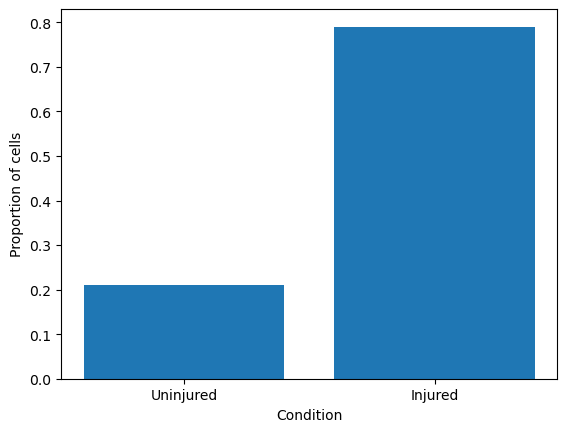

In [23]:
# Count only <1 and >7 bins
counts = adata_filtered_krt5_tp63_2.obs["life_span_bin"].value_counts()
counts = counts[["< 1 day", "> 7 days"]]

# Map categories to new labels
counts = counts.rename({
    "< 1 day": "Uninjured",
    "> 7 days": "Injured"
})

# Convert to proportions
proportions = counts / counts.sum()

# Plot
plt.bar(proportions.index, proportions.values)
plt.xlabel("Condition")
plt.ylabel("Proportion of cells")
plt.show()

life_span_bin
Uninjured     3362
Injured      12665
Name: count, dtype: int64


/tmp/ipykernel_3755809/3736742820.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["condition"] = df["life_span_bin"].replace({


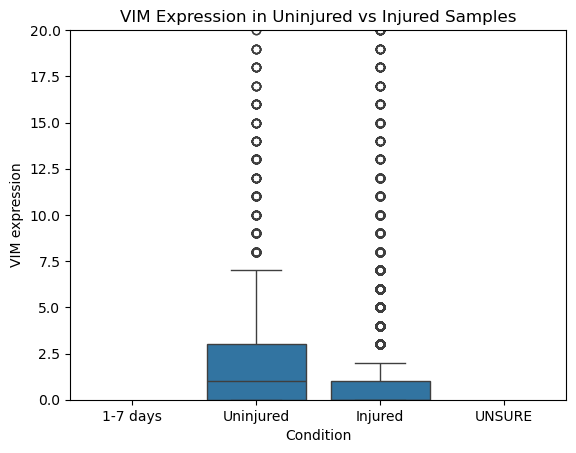

In [44]:
# Subset to only <1 day and >7 days
df = adata_filtered_krt5_tp63_2.obs.copy()
df = df[df["life_span_bin"].isin(["< 1 day", "> 7 days"])]

df["condition"] = df["life_span_bin"].replace({
    "< 1 day": "Uninjured",
    "> 7 days": "Injured"
})

sns.boxplot(data=df, x="condition", y="VIM")

plt.xlabel("Condition")
plt.ylabel("VIM expression")
plt.ylim(0, 20)
plt.title("VIM Expression in Uninjured vs Injured Samples")
plt.show()

### CLUSTERING 

In [ ]:
#Send adata object to GPU.
rsc.get.anndata_to_GPU(adata)

In [ ]:
#Log transform and scale data. NOTE: If you want to normalize the data, you will need to add the line yourself.
rsc.pp.log1p(adata)
rsc.scale(adata)

In [ ]:
#Run PCA.
rsc.tl.pca(adata, n_comps=100)

In [ ]:
#Send adata object back to CPU.
rsc.get.anndata_to_CPU(adata)

In [ ]:
#Neighbours and umap.
rsc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
rsc.tl.umap(adata)

In [ ]:
#Leiden clustering, add resolutions as needed.
rsc.tl.leiden(adata, resolution=0.5, key_added="leiden_0.5")
rsc.tl.leiden(adata, resolution=1.0, key_added="leiden_1.0")
rsc.tl.leiden(adata, resolution=1.5, key_added="leiden_1.5")
rsc.tl.leiden(adata, resolution=2.0, key_added="leiden_2.0")

In [ ]:
#Plot umap, change color argument to show different resolutions.
sc.pl.umap(adata, color=["leiden_0.5"], legend_loc="on data")

In [ ]:
#Write adata to h5ad file. Change file name as needed.
sc.write("rapids_output.h5ad", adata)